In [36]:
import pandas as pd 

In [37]:
df=pd.read_csv(r"C:/Users/Vaibhavi/Desktop/new data.csv")
print(df)               

     Age  Gender    Occupation  Annual_Income     Education City_Tier  \
0     59  Female       Retired         546213  Postgraduate    Tier-2   
1     49  Female      Business        1687018      Graduate    Tier-2   
2     35    Male  Professional        1303275  Postgraduate    Tier-2   
3     28  Female      Business        1620523      Graduate    Tier-2   
4     41    Male      Salaried         470205  Postgraduate    Tier-2   
..   ...     ...           ...            ...           ...       ...   
995   28  Female      Salaried         939888      Graduate    Tier-2   
996   48    Male      Salaried         924913  Postgraduate    Tier-1   
997   51  Female      Salaried         772617           HSC    Tier-2   
998   29  Female       Student         251567      Graduate    Tier-2   
999   49  Female      Salaried        1131187           HSC    Tier-1   

    Existing_Bank_Account  Credit_Score  Investment_Experience  \
0                      No           585                  

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1000 non-null   int64 
 1   Gender                 1000 non-null   object
 2   Occupation             1000 non-null   object
 3   Annual_Income          1000 non-null   int64 
 4   Education              1000 non-null   object
 5   City_Tier              1000 non-null   object
 6   Existing_Bank_Account  1000 non-null   object
 7   Credit_Score           1000 non-null   int64 
 8   Investment_Experience  1000 non-null   int64 
 9   Savings_Amount         1000 non-null   int64 
 10  Digital_Banking_Usage  1000 non-null   object
 11  Previous_Investments   827 non-null    object
 12  Demat_Account_Open     1000 non-null   int64 
dtypes: int64(6), object(7)
memory usage: 101.7+ KB


In [39]:
df=df.drop("City_Tier",axis=1)
print(df)

     Age  Gender    Occupation  Annual_Income     Education  \
0     59  Female       Retired         546213  Postgraduate   
1     49  Female      Business        1687018      Graduate   
2     35    Male  Professional        1303275  Postgraduate   
3     28  Female      Business        1620523      Graduate   
4     41    Male      Salaried         470205  Postgraduate   
..   ...     ...           ...            ...           ...   
995   28  Female      Salaried         939888      Graduate   
996   48    Male      Salaried         924913  Postgraduate   
997   51  Female      Salaried         772617           HSC   
998   29  Female       Student         251567      Graduate   
999   49  Female      Salaried        1131187           HSC   

    Existing_Bank_Account  Credit_Score  Investment_Experience  \
0                      No           585                      4   
1                     Yes           900                      3   
2                     Yes           755      

In [40]:
df.drop_duplicates(inplace=True)
print(df)

     Age  Gender    Occupation  Annual_Income     Education  \
0     59  Female       Retired         546213  Postgraduate   
1     49  Female      Business        1687018      Graduate   
2     35    Male  Professional        1303275  Postgraduate   
3     28  Female      Business        1620523      Graduate   
4     41    Male      Salaried         470205  Postgraduate   
..   ...     ...           ...            ...           ...   
995   28  Female      Salaried         939888      Graduate   
996   48    Male      Salaried         924913  Postgraduate   
997   51  Female      Salaried         772617           HSC   
998   29  Female       Student         251567      Graduate   
999   49  Female      Salaried        1131187           HSC   

    Existing_Bank_Account  Credit_Score  Investment_Experience  \
0                      No           585                      4   
1                     Yes           900                      3   
2                     Yes           755      

In [41]:
mean_Income=df['Annual_Income'].mean()
median_Income=df['Annual_Income'].median()
mode_Income=df['Annual_Income'].mode()
print(f"Mean Income: {mean_Income:.2f}")
print(f"Median Income: {median_Income}")
print(f"Mode Income: {mode_Income}")


Mean Income: 855808.30
Median Income: 744338.5
Mode Income: 0    1686585
Name: Annual_Income, dtype: int64


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Separate features (X) and the target variable (y)
X = df.drop(columns=['Demat_Account_Open'])
y = df['Demat_Account_Open']

# 2. Convert categorical/text columns (Gender, Occupation, etc.) into numbers
X = pd.get_dummies(X, drop_first=True)

# 3. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = RandomForestClassifier(random_state=200)
model.fit(X_train, y_train)

# 5. Make predictions and evaluate how well it did
y_pred = model.predict(X_test)

#6.confusion matrix 
matrix=confusion_matrix(y_test,y_pred)
print(f"confusion Matrix:\n{matrix}")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))
print("Classification Report:")

confusion Matrix:
[[ 38  26]
 [  9 127]]
Model Accuracy: 82.50%

              precision    recall  f1-score   support

           0       0.81      0.59      0.68        64
           1       0.83      0.93      0.88       136

    accuracy                           0.82       200
   macro avg       0.82      0.76      0.78       200
weighted avg       0.82      0.82      0.82       200

Classification Report:


In [43]:
import pandas as pd
import string as str 

data = {
    'Age': [24, 32, 45, 28, 38, 22, 50, 30],
    'Income': [25000, 75000, 120000, 35000, 90000, 18000, 150000, 45000],
    'Experience': ["yes","no","yes","yes","no","no","yes","yes"],
    'Demat': [0, 1, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

In [44]:

df['Experience']=df['Experience'].map({
    'yes':1,
    'no':0
})

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X = df[['Age','Income','Experience']]
y = df['Demat']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
new_person = [[35, 85000, 4]]  # Age, Income, Experience

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Likely to have/open a Demat Account")
else:
    print("Unlikely to have/open a Demat Account")

Likely to have/open a Demat Account


C:\Users\Vaibhavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [48]:
age = int(input("Enter Age: "))
income = int(input("Enter Monthly Income: "))
experience = input("Enter Investment Experience (yes/no): ")
if experience=="yes":
    experience=1
else:
   experience=0
prediction = model.predict([[age, income, experience]])

print("Prediction:", "Yes" if prediction[0] == 1 else "No")

Enter Age:  41
Enter Monthly Income:  500000
Enter Investment Experience (yes/no):  31


Prediction: Yes


C:\Users\Vaibhavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [49]:
import pickle

# Load the saved model from the file
pickle.dump(model,open("demat.pkl","wb"))
pickle.dump(X.columns.tolist(),open("feature_columns.pkl","wb"))
print("file saved successfully")

file saved successfully


In [50]:
new_person = [[20,40000,6]]  # Age, Income, Experience

prediction = model.predict(new_person)
if prediction[0] == 1:
    print("Likely to have/open a Demat Account")
else:
    print("Unlikely to have/open a Demat Account")

Unlikely to have/open a Demat Account


C:\Users\Vaibhavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [51]:
age = int(input("Enter Age: "))
income = int(input("Enter Monthly Income: "))
experience = input("Enter Investment Experience (yes/no): ")
if experience=="yes":
    experience=1
else:
   experience=0
prediction = model.predict([[age, income, experience]])

print("Prediction:", "Yes" if prediction[0] == 1 else "No")

Enter Age:  32
Enter Monthly Income:  50000
Enter Investment Experience (yes/no):  21


Prediction: No


C:\Users\Vaibhavi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Updated dataset with 'Credit_Points'
data = {
    'Age': [24, 32, 45, 28, 38, 22, 50, 30],
    'Income': [25000, 75000, 120000, 35000, 90000, 18000, 150000, 45000],
    'Experience': ["yes", "no", "yes", "yes", "no", "no", "yes", "yes"],
    'Credit_Points': [650, 710, 790, 620, 740, 580, 820, 680],  # New Feature
    'Demat': [0, 1, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

# 2. Encode categorical 'Experience' column
df['Experience'] = df['Experience'].map({'yes': 1, 'no': 0})

# 3. Define Features (X) including Credit_Points, and Target (y)
X = df[['Age', 'Income', 'Experience', 'Credit_Points']]
y = df['Demat']

# 4. Split and train the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Take user inputs for prediction
print("--- Enter Details for Prediction ---")
age = int(input("Enter Age: "))
income = int(input("Enter Monthly Income: "))
experience_input = input("Enter Investment Experience (yes/no): ").strip().lower()
credit_points = int(input("Enter Credit Points (e.g., 300-850): "))

# Map experience input to 1 or 0
experience = 1 if experience_input == "yes" else 0

# Create a DataFrame for the new input to keep feature names intact (fixes the warning)
new_person = pd.DataFrame([{
    'Age': age,
    'Income': income,
    'Experience': experience,
    'Credit_Points': credit_points
}])

# 6. Predict
prediction = model.predict(new_person)

print("\n--- Result ---")
if prediction[0] == 1:
    print("Prediction: Likely to have/open a Demat Account")
else:
    print("Prediction: Unlikely to have/open a Demat Account")

--- Enter Details for Prediction ---


Enter Age:  49
Enter Monthly Income:  500000
Enter Investment Experience (yes/no):  21
Enter Credit Points (e.g., 300-850):  700



--- Result ---
Prediction: Likely to have/open a Demat Account


C:\Users\Vaibhavi\AppData\Local\Temp\ipykernel_16088\3054381389.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Accounts_Opened', data=df_monthly, palette='viridis')


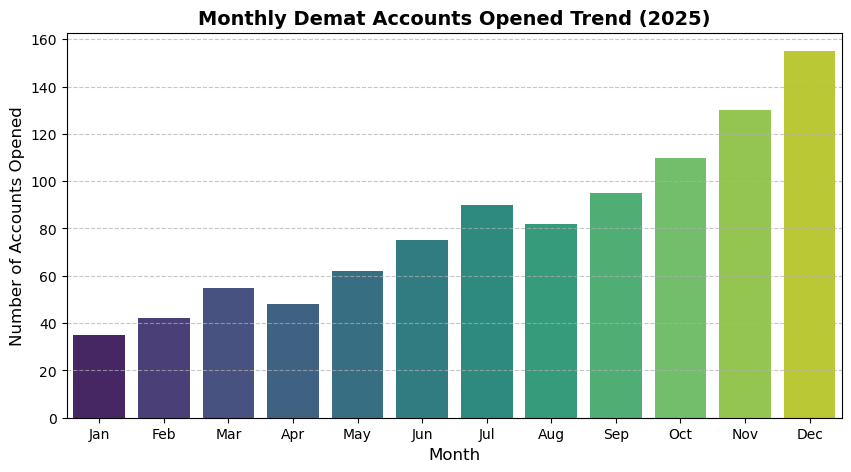

In [53]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create dummy historical monthly data
monthly_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Accounts_Opened': [35, 42, 55, 48, 62, 75, 90, 82, 95, 110, 130, 155]
}
df_monthly = pd.DataFrame(monthly_data)
# 2. Plot the graphical representation
plt.figure(figsize=(10, 5))
sns.barplot(x='Month', y='Accounts_Opened', data=df_monthly, palette='viridis')
# Customizing the chart
plt.title('Monthly Demat Accounts Opened Trend (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accounts Opened', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Display the chart
plt.show()

In [54]:
import joblib
# Assuming 'model' or 'pipeline' is your trained model variable name
# It's best if this is a scikit-learn Pipeline containing your encoders/scalers
joblib.dump(model,'demat_model.pkl')
print("Model saved successfully!")

Model saved successfully!
